#  Exploratory Data Analysis
**Ethiopia Financial Inclusion Forecasting — Selam Analytics**

Uses the Task 1 output (`data/raw/ethiopia_fi_unified_data.csv`, 73 records) via
`src/data_loader.py`. Figures are saved to `reports/figures/` as well as shown inline.

A note on approach before diving in: several indicators added during Task 1 enrichment
have only **one or two** data points. Where that's true, this notebook says so explicitly
rather than presenting a trend line or correlation that the data can't actually support.


In [2]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
sns.set_style("whitegrid")
FIG_DIR = Path.cwd().parent / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

from src.data_loader import (
    load_unified_data, load_reference_codes,
    get_observations, get_events, get_impact_links, get_targets,
    link_events_to_impacts, summarize_counts, get_indicator_coverage,
    get_events_catalog, review_impact_links,
)

df = load_unified_data()
reference = load_reference_codes()
print(f"Loaded {len(df)} records")


Loaded 73 records


## 1. Dataset Overview


In [3]:
for name, counts in summarize_counts(df).items():
    print(f"--- {name} ---")
    print(counts, "\n")


--- record_type ---
record_type
observation    42
impact_link    17
event          11
target          3
Name: count, dtype: int64 

--- pillar ---
pillar
ACCESS           29
USAGE            22
NaN              11
GENDER            7
AFFORDABILITY     4
Name: count, dtype: int64 

--- source_type ---
source_type
survey        19
NaN           18
operator      16
regulator      8
research       4
policy         3
news           3
calculated     2
Name: count, dtype: int64 

--- confidence ---
confidence
high      53
medium    18
NaN        1
low        1
Name: count, dtype: int64 



### Temporal coverage: which years have data for which indicators?


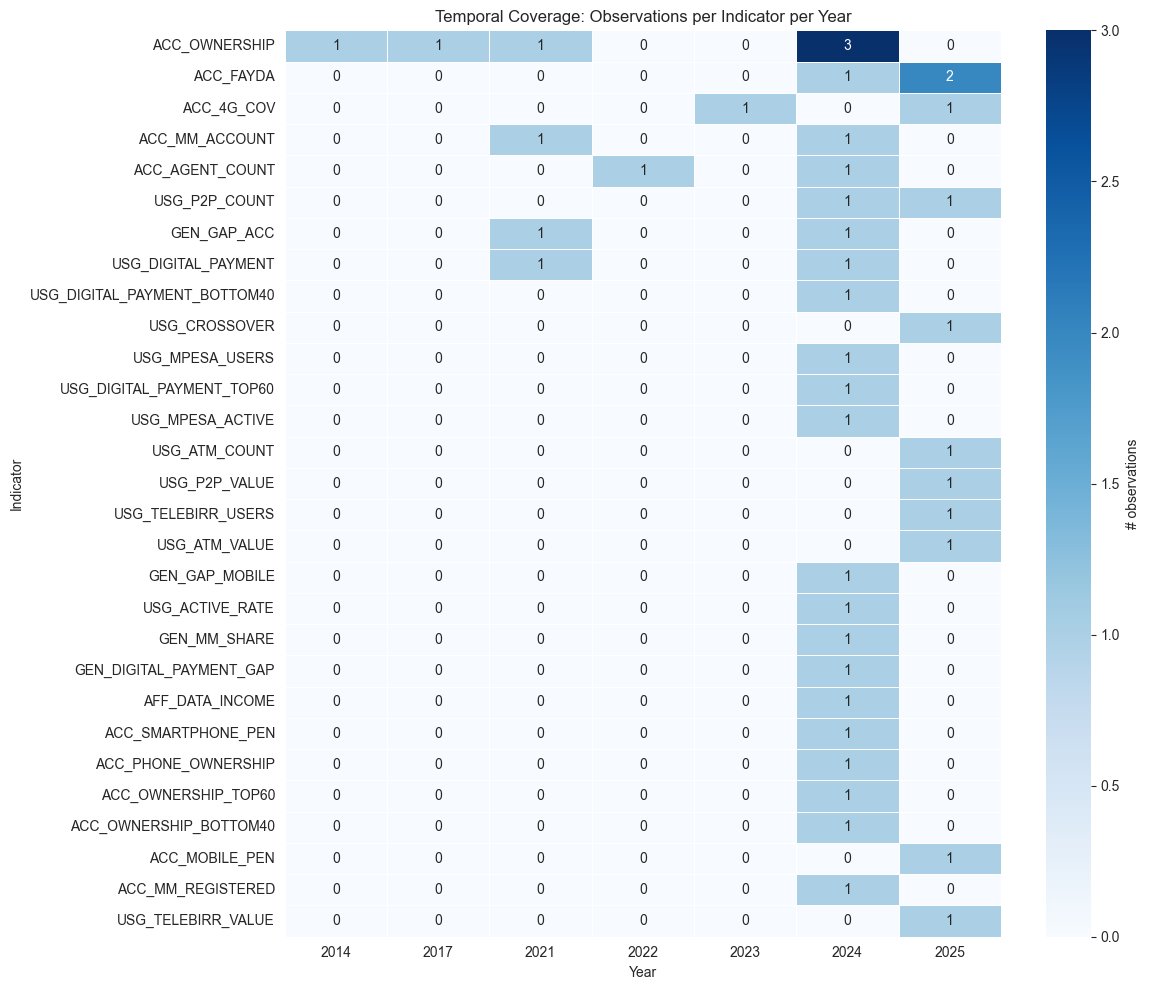

In [4]:
obs = get_observations(df).copy()
obs["year"] = obs["observation_date"].dt.year

coverage_matrix = (
    obs.pivot_table(index="indicator_code", columns="year", values="value_numeric", aggfunc="count")
    .fillna(0)
    .astype(int)
)
coverage_matrix = coverage_matrix.loc[coverage_matrix.sum(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(coverage_matrix, cmap="Blues", cbar_kws={"label": "# observations"},
            linewidths=0.5, linecolor="white", annot=True, fmt="d", ax=ax)
ax.set_title("Temporal Coverage: Observations per Indicator per Year")
ax.set_xlabel("Year")
ax.set_ylabel("Indicator")
plt.tight_layout()
plt.savefig(FIG_DIR / "temporal_coverage_heatmap.png", dpi=150)
plt.show()


### Data quality: confidence level distribution


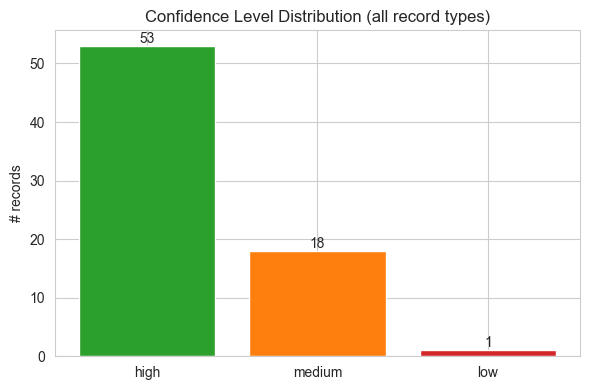

1 records are low-confidence -- treat conclusions drawn from these with extra caution.


In [5]:
fig, ax = plt.subplots(figsize=(6, 4))
conf_counts = df["confidence"].value_counts().reindex(["high", "medium", "low"]).dropna()
colors = {"high": "#2ca02c", "medium": "#ff7f0e", "low": "#d62728"}
ax.bar(conf_counts.index, conf_counts.values, color=[colors[c] for c in conf_counts.index])
ax.set_title("Confidence Level Distribution (all record types)")
ax.set_ylabel("# records")
for i, v in enumerate(conf_counts.values):
    ax.text(i, v + 0.5, str(v), ha="center")
plt.tight_layout()
plt.savefig(FIG_DIR / "confidence_distribution.png", dpi=150)
plt.show()

print(f"{(df['confidence']=='low').sum()} records are low-confidence -- treat conclusions drawn from these with extra caution.")


### Sparse coverage: which indicators have the least data?


In [6]:
coverage = get_indicator_coverage(df)
sparse = coverage[coverage["n_records"] <= 1]
print(f"{len(sparse)} of {len(coverage)} indicators have only 1 observation (no trend possible):")
sparse


21 of 29 indicators have only 1 observation (no trend possible):


,n_records,first_observed,last_observed
indicator_code,,,
USG_DIGITAL_PAYMENT_BOTTOM40,1,2024-11-29,2024-11-29
USG_CROSSOVER,1,2025-07-07,2025-07-07
USG_MPESA_USERS,1,2024-12-31,2024-12-31
USG_DIGITAL_PAYMENT_TOP60,1,2024-11-29,2024-11-29
USG_MPESA_ACTIVE,1,2024-12-31,2024-12-31
USG_ATM_COUNT,1,2025-07-07,2025-07-07
USG_P2P_VALUE,1,2025-07-07,2025-07-07
USG_TELEBIRR_USERS,1,2025-06-30,2025-06-30
USG_ATM_VALUE,1,2025-07-07,2025-07-07


**Note:** the project brief's overview table cites a 2011 Account Ownership figure (14%),
but no 2011 row exists in `ethiopia_fi_unified_data.csv` -- the earliest actual `ACC_OWNERSHIP`
observation is 2014. This is a data gap worth flagging, not assuming away: all "since 2011"
framing in this analysis is really "since 2014" as far as the dataset itself is concerned.


## 2. Access Analysis


In [7]:
acc = get_observations(df, pillar="ACCESS")
acc_ownership = acc[acc["indicator_code"] == "ACC_OWNERSHIP"].sort_values("observation_date")
acc_ownership[["record_id", "value_numeric", "observation_date", "gender", "source_name"]]


,record_id,value_numeric,observation_date,gender,source_name
0,REC_0001,22.0,2014-12-31,all,Global Findex 2014
1,REC_0002,35.0,2017-12-31,all,Global Findex 2017
2,REC_0003,46.0,2021-12-31,all,Global Findex 2021
3,REC_0004,56.0,2024-11-29,male,Global Findex 2021
4,REC_0005,36.0,2024-11-29,female,Global Findex 2021
5,REC_0006,49.0,2024-11-29,all,Global Findex 2024


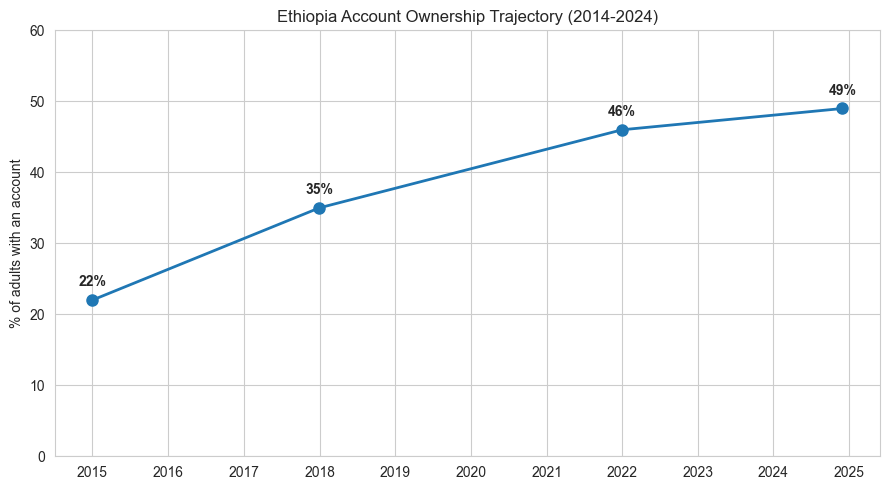

In [8]:
# National trajectory only (gender='all') -- the male/female rows are a separate 2024 snapshot
national = acc_ownership[acc_ownership["gender"] == "all"]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(national["observation_date"], national["value_numeric"], marker="o", markersize=8, linewidth=2)
for _, row in national.iterrows():
    ax.annotate(f"{row['value_numeric']:.0f}%", (row["observation_date"], row["value_numeric"]),
                textcoords="offset points", xytext=(0, 10), ha="center", fontweight="bold")
ax.set_title("Ethiopia Account Ownership Trajectory (2014-2024)")
ax.set_ylabel("% of adults with an account")
ax.set_ylim(0, 60)
plt.tight_layout()
plt.savefig(FIG_DIR / "access_trajectory.png", dpi=150)
plt.show()


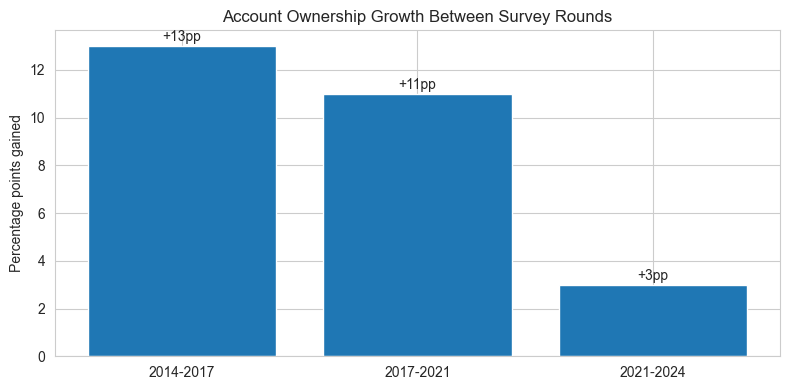

,observation_date,value_numeric,pp_change,years_elapsed,pp_per_year
0,2014-12-31,22.0,NaN,NaN,NaN
1,2017-12-31,35.0,13.0,3.0,4.333333
2,2021-12-31,46.0,11.0,4.0,2.750000
3,2024-11-29,49.0,3.0,3.0,1.000000


In [9]:
# Growth rates between survey years
national = national.reset_index(drop=True)
national["pp_change"] = national["value_numeric"].diff()
national["years_elapsed"] = national["observation_date"].dt.year.diff()
national["pp_per_year"] = national["pp_change"] / national["years_elapsed"]

fig, ax = plt.subplots(figsize=(8, 4))
labels = [f"{national['observation_date'].dt.year.iloc[i-1]}-{national['observation_date'].dt.year.iloc[i]}"
          for i in range(1, len(national))]
ax.bar(labels, national["pp_change"].dropna(), color="#1f77b4")
ax.set_title("Account Ownership Growth Between Survey Rounds")
ax.set_ylabel("Percentage points gained")
for i, v in enumerate(national["pp_change"].dropna()):
    ax.text(i, v + 0.2, f"+{v:.0f}pp", ha="center")
plt.tight_layout()
plt.savefig(FIG_DIR / "access_growth_rates.png", dpi=150)
plt.show()

national[["observation_date", "value_numeric", "pp_change", "years_elapsed", "pp_per_year"]]


### Gender gap


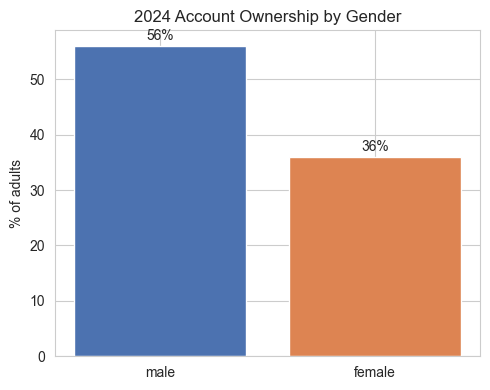

2024 gender gap: 20pp (male 56% vs female 36%)
CAVEAT: this 56/36 figure is flagged in data_enrichment_log.md as conflicting with a second source reporting 57/42 for the same 2024 round -- treat the exact gap size as approximate pending verification against primary Findex microdata.


In [10]:
gender_2024 = acc_ownership[acc_ownership["gender"].isin(["male", "female"])]

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(gender_2024["gender"], gender_2024["value_numeric"], color=["#4c72b0", "#dd8452"])
ax.set_title("2024 Account Ownership by Gender")
ax.set_ylabel("% of adults")
for i, v in enumerate(gender_2024["value_numeric"]):
    ax.text(i, v + 1, f"{v:.0f}%", ha="center")
plt.tight_layout()
plt.savefig(FIG_DIR / "access_gender_gap.png", dpi=150)
plt.show()

gap = gender_2024["value_numeric"].max() - gender_2024["value_numeric"].min()
print(f"2024 gender gap: {gap:.0f}pp (male {gender_2024[gender_2024.gender=='male'].value_numeric.values[0]:.0f}% "
      f"vs female {gender_2024[gender_2024.gender=='female'].value_numeric.values[0]:.0f}%)")
print("CAVEAT: this 56/36 figure is flagged in data_enrichment_log.md as conflicting with a "
      "second source reporting 57/42 for the same 2024 round -- treat the exact gap size as "
      "approximate pending verification against primary Findex microdata.")


In [11]:
# Trend in GEN_GAP_ACC (2 points -- directional only, not a robust trend)
gen_gap = get_observations(df, pillar="GENDER")
gen_gap_acc = gen_gap[gen_gap["indicator_code"] == "GEN_GAP_ACC"].sort_values("observation_date")
gen_gap_acc[["value_numeric", "observation_date", "source_name"]]


,value_numeric,observation_date,source_name
26,20.0,2021-12-31,Global Findex 2021
27,18.0,2024-11-29,Global Findex 2024


### Urban vs. rural ownership — **data gap**

Every observation in this dataset has `location = "national"`. There is no urban/rural
disaggregation anywhere in `ethiopia_fi_unified_data.csv`, so this comparison **cannot be
made** with the current data. Per Sheet D (Market Nuances) of the enrichment guide, bank
branches and infrastructure are heavily concentrated in Addis Ababa, so a real urban/rural
gap almost certainly exists -- it's just not captured here. Flagging as a priority gap for
future enrichment rather than fabricating a number.


In [12]:
location_values = df["location"].dropna().unique()
print("Distinct 'location' values present in the dataset:", location_values)


Distinct 'location' values present in the dataset: ['national']


### Investigating the 2021→2024 slowdown

Account ownership grew only **+3pp** (46%→49%) between 2021 and 2024, despite Telebirr and
M-Pesa launching in between and tens of millions of mobile accounts being opened. Three
Task-1-enriched data points help explain why:


In [13]:
mm_registered = get_observations(df)[get_observations(df)["indicator_code"] == "ACC_MM_REGISTERED"]
mm_active = get_observations(df)[get_observations(df)["indicator_code"] == "ACC_MM_ACCOUNT"]
agents = get_observations(df)[get_observations(df)["indicator_code"] == "ACC_AGENT_COUNT"].sort_values("observation_date")

print("Registered mobile money accounts (2024):", f"{mm_registered['value_numeric'].values[0]:,.0f}")
print("Findex active mobile money use (2024):   ", f"{mm_active[mm_active.observation_date.dt.year==2024]['value_numeric'].values[0]:.2f}%")
print()
print("Agent network growth:")
print(agents[["observation_date", "value_numeric"]].to_string(index=False))


Registered mobile money accounts (2024): 90,000,000
Findex active mobile money use (2024):    9.45%

Agent network growth:
observation_date  value_numeric
      2022-09-30       200000.0
      2024-06-30       216000.0


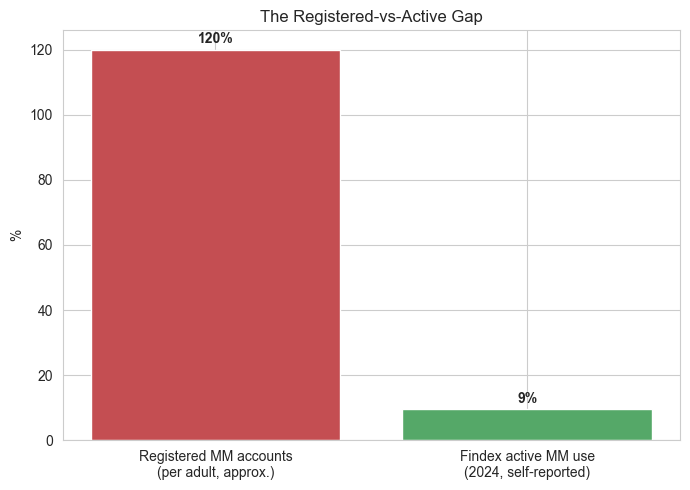


Approx. 120 registered mobile accounts per 100 adults, vs. only 9.4% reporting active use in the last 12 months -- consistent with widespread duplicate/dormant accounts, exactly the gap the Market Nuances guide (Sheet D) warns about.


In [14]:
# Rough per-adult estimate: Ethiopia's adult (15+) population is ~75M as of 2024
# (UN population estimates). This is an approximation for illustration, not a precise figure.
ADULT_POP_ESTIMATE = 75_000_000
registered_per_adult = mm_registered["value_numeric"].values[0] / ADULT_POP_ESTIMATE * 100

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(
    ["Registered MM accounts\n(per adult, approx.)", "Findex active MM use\n(2024, self-reported)"],
    [registered_per_adult, mm_active[mm_active.observation_date.dt.year==2024]["value_numeric"].values[0]],
    color=["#c44e52", "#55a868"],
)
ax.set_ylabel("%")
ax.set_title("The Registered-vs-Active Gap")
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 2, f"{h:.0f}%", ha="center", fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "registered_vs_active_gap.png", dpi=150)
plt.show()

print(f"\nApprox. {registered_per_adult:.0f} registered mobile accounts per 100 adults, "
      f"vs. only {mm_active[mm_active.observation_date.dt.year==2024]['value_numeric'].values[0]:.1f}% "
      "reporting active use in the last 12 months -- consistent with widespread duplicate/"
      "dormant accounts, exactly the gap the Market Nuances guide (Sheet D) warns about.")


**Working hypothesis for the slowdown**: mass mobile-money account *opening* (Telebirr,
M-Pesa) is not the same as *first-time* account ownership counted by Findex. Ethiopia's Market
Nuances note that bank accounts were already fairly accessible pre-2021 and mobile-money-only
users are rare (~0.5%) -- so most new mobile money accounts likely belong to people who
**already had a bank account**, converting them from "banked, no mobile money" to "banked,
has mobile money" without moving the headline ACC_OWNERSHIP number at all. Agent network
growth also nearly stalled (200k→216k, 2022-2024) relative to account growth, capping how many
genuinely new users could realistically be reached and served.


## 3. Usage (Digital Payments) Analysis


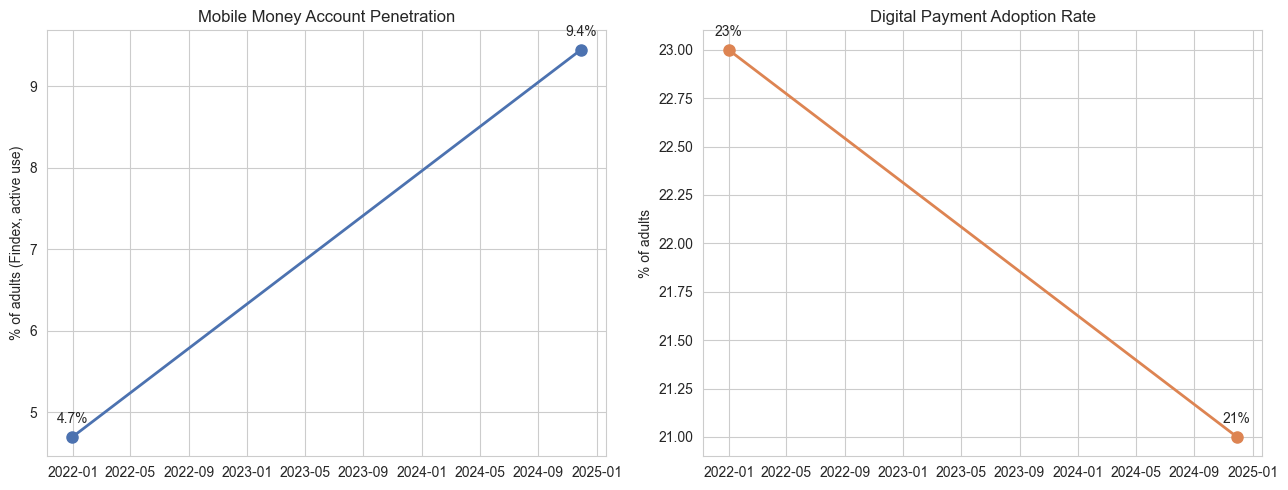

In [15]:
usg = get_observations(df, pillar="USAGE")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

mm = usg[usg["indicator_code"] == "ACC_MM_ACCOUNT"].sort_values("observation_date") if "ACC_MM_ACCOUNT" in usg["indicator_code"].values else acc[acc["indicator_code"]=="ACC_MM_ACCOUNT"].sort_values("observation_date")
axes[0].plot(mm["observation_date"], mm["value_numeric"], marker="o", markersize=8, linewidth=2, color="#4c72b0")
for _, row in mm.iterrows():
    axes[0].annotate(f"{row['value_numeric']:.1f}%", (row["observation_date"], row["value_numeric"]),
                      textcoords="offset points", xytext=(0, 10), ha="center")
axes[0].set_title("Mobile Money Account Penetration")
axes[0].set_ylabel("% of adults (Findex, active use)")

dp = usg[usg["indicator_code"] == "USG_DIGITAL_PAYMENT"].sort_values("observation_date")
axes[1].plot(dp["observation_date"], dp["value_numeric"], marker="o", markersize=8, linewidth=2, color="#dd8452")
for _, row in dp.iterrows():
    axes[1].annotate(f"{row['value_numeric']:.0f}%", (row["observation_date"], row["value_numeric"]),
                      textcoords="offset points", xytext=(0, 10), ha="center")
axes[1].set_title("Digital Payment Adoption Rate")
axes[1].set_ylabel("% of adults")

plt.tight_layout()
plt.savefig(FIG_DIR / "usage_trends.png", dpi=150)
plt.show()


Both series only have **two** data points (2021, 2024) -- directionally informative
(both grew modestly), but not enough to fit a real trend line without leaning heavily on the
event-effects model built in Task 3.

**Digital payment figure caveat**: the 2024 value (21%) is the better-corroborated of two
conflicting sources found during enrichment (the project brief cites ~35%) -- see
`data_enrichment_log.md` for the full reasoning. Treat with medium-high confidence, not certainty.


### Payment use cases — 2024/2025 snapshot

Most operator-reported usage indicators (Telebirr, M-Pesa, P2P, ATM) are each a **single
snapshot**, taken at different dates in 2024-2025 -- not a time series. Presented here as a
cross-sectional snapshot of the payments landscape rather than a trend.


In [16]:
snapshot_codes = ["USG_TELEBIRR_USERS", "USG_MPESA_USERS", "USG_MPESA_ACTIVE",
                   "USG_P2P_COUNT", "USG_ATM_COUNT", "USG_ACTIVE_RATE"]
snapshot = get_observations(df)[get_observations(df)["indicator_code"].isin(snapshot_codes)]
snapshot = snapshot.sort_values("observation_date")
snapshot[["indicator_code", "indicator", "value_numeric", "unit", "observation_date", "source_name"]]


,indicator_code,indicator,value_numeric,unit,observation_date,source_name
14,USG_P2P_COUNT,P2P Transaction Count,49700000.0,transactions,2024-07-07,EthSwitch Annual Report
22,USG_MPESA_USERS,M-Pesa Registered Users,10800000.0,users,2024-12-31,Safaricom Results
23,USG_MPESA_ACTIVE,M-Pesa 90-Day Active Users,7100000.0,users,2024-12-31,Safaricom Results
24,USG_ACTIVE_RATE,Mobile Money Activity Rate,66.0,%,2024-12-31,Calculated
20,USG_TELEBIRR_USERS,Telebirr Registered Users,54840000.0,users,2025-06-30,Ethio Telecom Report
15,USG_P2P_COUNT,P2P Transaction Count,128300000.0,transactions,2025-07-07,EthSwitch Annual Report
17,USG_ATM_COUNT,ATM Transaction Count,119300000.0,transactions,2025-07-07,EthSwitch Annual Report


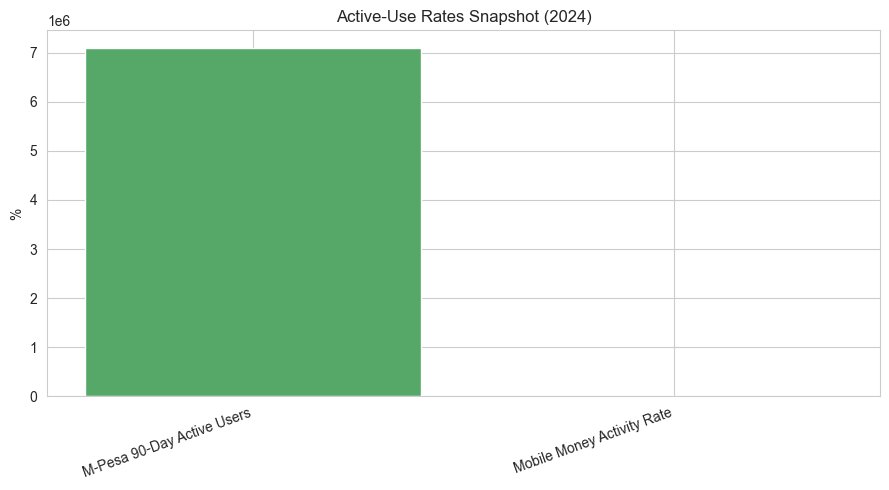

In [17]:
fig, ax = plt.subplots(figsize=(9, 5))
plot_data = snapshot[snapshot["unit"].isin(["%", "percentage"])] if "unit" in snapshot.columns else snapshot
# Fall back to plotting whatever's numeric and roughly comparable (percent-like) indicators
pct_rows = snapshot[snapshot["indicator_code"].isin(["USG_MPESA_ACTIVE", "USG_ACTIVE_RATE"])]
if not pct_rows.empty:
    ax.bar(pct_rows["indicator"], pct_rows["value_numeric"], color="#55a868")
    ax.set_ylabel("%")
    ax.set_title("Active-Use Rates Snapshot (2024)")
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "usage_active_rates_snapshot.png", dpi=150)
    plt.show()
else:
    print("No comparable percentage-based rows to plot in this snapshot.")


**P2P vs. ATM crossover** (`USG_CROSSOVER`, an existing starter-data milestone
indicator) is itself one of the clearest Usage signals in the dataset -- P2P digital transfers
surpassing ATM cash withdrawals in volume is a strong qualitative marker of the shift toward
digital payments, even without a long time series behind it.


In [18]:
crossover = get_observations(df)[get_observations(df)["indicator_code"] == "USG_CROSSOVER"]
crossover[["value_numeric", "unit", "observation_date", "source_name", "notes"]]


,value_numeric,unit,observation_date,source_name,notes
19,1.08,ratio,2025-07-07,Calculated,NaN


## 4. Infrastructure and Enablers


In [19]:
enabler_codes = ["ACC_4G_COV", "ACC_MOBILE_PEN", "ACC_SMARTPHONE_PEN",
                  "ACC_PHONE_OWNERSHIP", "AFF_DATA_INCOME"]
enablers = get_observations(df)[get_observations(df)["indicator_code"].isin(enabler_codes)].sort_values("observation_date")
enablers[["indicator_code", "indicator", "value_numeric", "unit", "observation_date", "source_name", "confidence"]]


,indicator_code,indicator,value_numeric,unit,observation_date,source_name,confidence
8,ACC_4G_COV,4G Population Coverage,37.5,%,2023-06-30,Ethio Telecom LEAD Report,high
63,ACC_SMARTPHONE_PEN,Smartphone Penetration,16.0,%,2024-11-29,Birr Metrics (citing World Bank Global Findex ...,high
64,ACC_PHONE_OWNERSHIP,Mobile Phone Ownership,41.0,%,2024-11-29,Birr Metrics (citing World Bank Global Findex ...,high
25,AFF_DATA_INCOME,Data Affordability Index,2.0,% of GNI,2024-12-31,A4AI/ITU,medium
9,ACC_4G_COV,4G Population Coverage,70.8,%,2025-06-30,Ethio Telecom LEAD Report,high
10,ACC_MOBILE_PEN,Mobile Subscription Penetration,61.4,%,2025-12-31,DataReportal Digital 2026,high


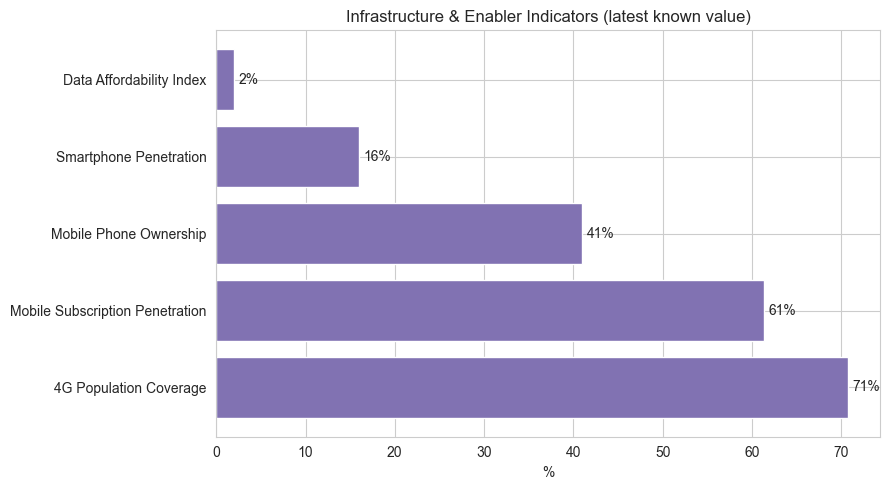

In [20]:
latest_enablers = enablers.sort_values("observation_date").groupby("indicator_code").last()

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(latest_enablers["indicator"], latest_enablers["value_numeric"], color="#8172b2")
ax.set_xlabel("%")
ax.set_title("Infrastructure & Enabler Indicators (latest known value)")
for i, v in enumerate(latest_enablers["value_numeric"]):
    ax.text(v + 0.5, i, f"{v:.0f}%", va="center")
plt.tight_layout()
plt.savefig(FIG_DIR / "infrastructure_enablers.png", dpi=150)
plt.show()


**Reading these together**: smartphone penetration (16%) is dramatically lower than mobile
phone ownership (41%), which is itself lower than 4G coverage (~70%+ per the starter data,
check exact figure above) -- i.e. the *network* has outpaced the *devices* people actually
own. This is a plausible leading-indicator bottleneck: expanding 4G coverage alone won't lift
digital Usage much further while most phones in use can't run banking/payment apps.

**No true "ATM density" (ATMs per 100k adults) or bank-branch-density indicator exists in this
dataset** -- only `USG_ATM_COUNT`/`USG_ATM_VALUE`, which are transaction counts/values, not a
density/coverage measure. Flagging this as a real gap for future enrichment: it's exactly the
kind of "Direct Correlation" indicator Sheet B of the enrichment guide calls out, and it isn't
here yet.

Correlating infrastructure against Findex outcomes with real statistical rigor isn't possible
with this data: `ACC_4G_COV` (2023, 2025), `ACC_SMARTPHONE_PEN` (2024) and `ACC_OWNERSHIP`
(2014, 2017, 2021, 2024) barely share any observation years. Section 6 addresses this
limitation directly rather than working around it.


## 5. Event Timeline and Visual Analysis


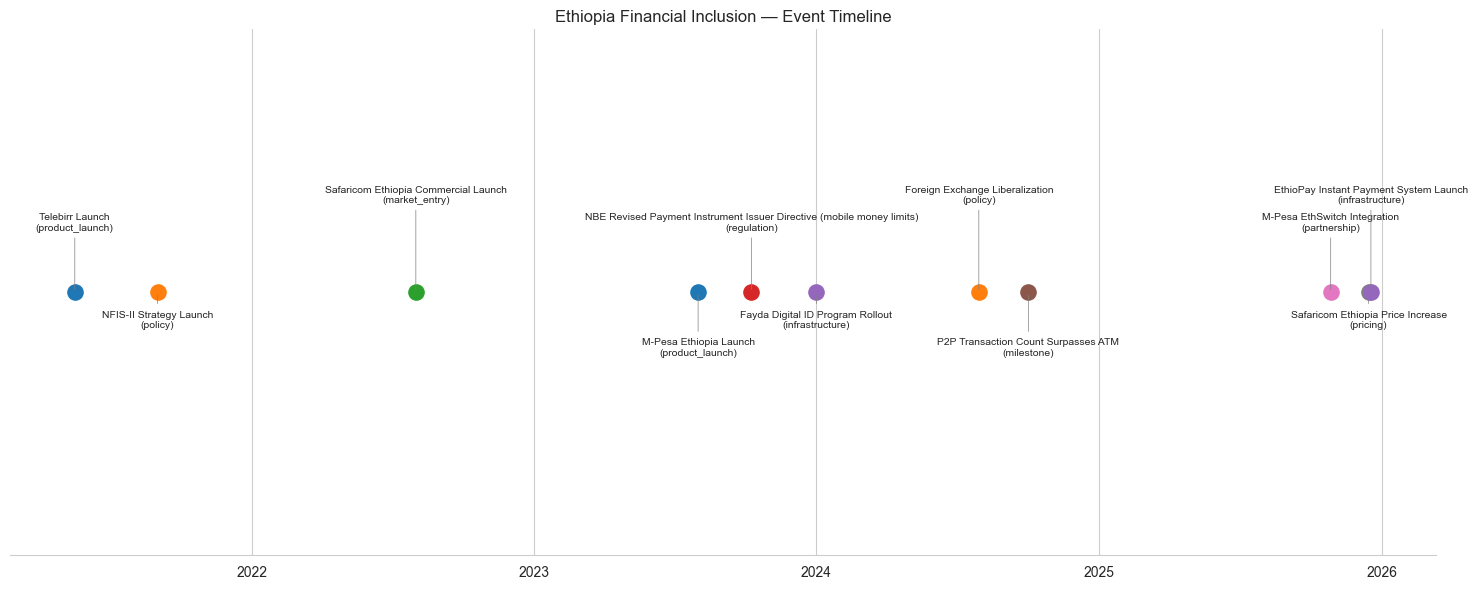

In [27]:
events = get_events_catalog(df).sort_values("observation_date").reset_index(drop=True)
category_colors = dict(zip(events["category"].unique(),
                            sns.color_palette("tab10", n_colors=events["category"].nunique())))

# Stagger labels across 4 vertical levels (not just 2) so events that fall close
# together in time (e.g. Dec 2025's two launches) don't overlap.
offsets = [45, -25, 65, -45]

fig, ax = plt.subplots(figsize=(15, 6))
for i, (_, row) in enumerate(events.iterrows()):
    ax.scatter(row["observation_date"], 0, s=120, color=category_colors[row["category"]], zorder=3)
    y_off = offsets[i % len(offsets)]
    ax.annotate(f"{row['indicator']}\n({row['category']})",
                (row["observation_date"], 0),
                textcoords="offset points", xytext=(0, y_off),
                ha="center", fontsize=7.5, rotation=0,
                arrowprops=dict(arrowstyle="-", lw=0.5, color="gray"))

ax.get_yaxis().set_visible(False)
ax.set_ylim(-2.2, 2.2)
ax.set_title("Ethiopia Financial Inclusion — Event Timeline")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.savefig(FIG_DIR / "event_timeline.png", dpi=150)
plt.show()

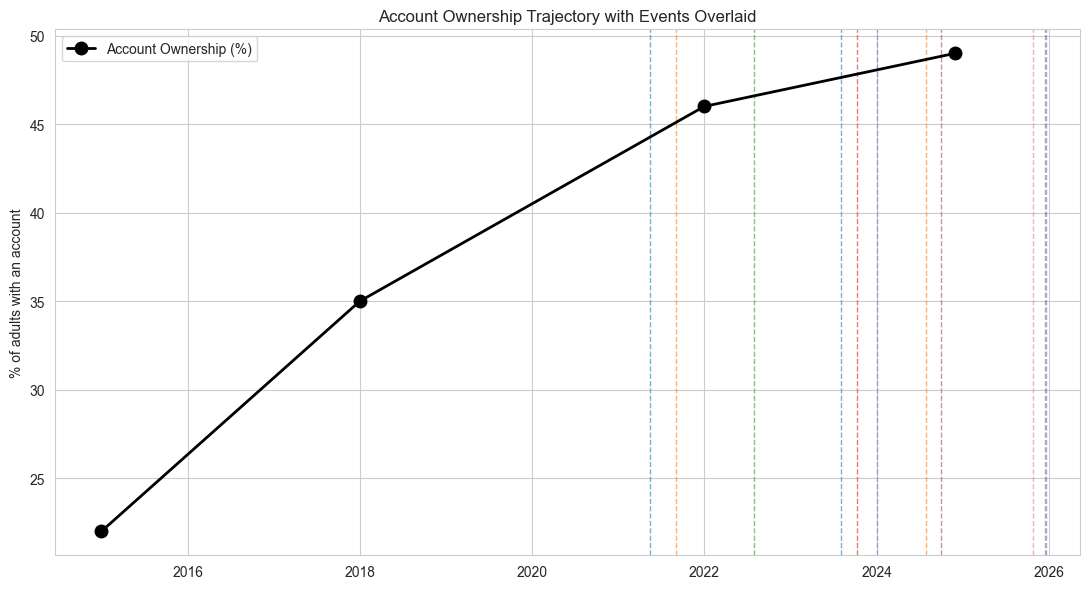

In [22]:
# Overlay events on the Access trajectory
fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(national["observation_date"], national["value_numeric"], marker="o", markersize=9,
        linewidth=2, color="black", zorder=3, label="Account Ownership (%)")

for _, row in events.iterrows():
    ax.axvline(row["observation_date"], color=category_colors[row["category"]], linestyle="--", alpha=0.6, linewidth=1)

ax.set_title("Account Ownership Trajectory with Events Overlaid")
ax.set_ylabel("% of adults with an account")
ax.legend(loc="upper left")
plt.tight_layout()
plt.savefig(FIG_DIR / "access_with_events_overlay.png", dpi=150)
plt.show()


**Visual read, with an important caveat**: Findex is only surveyed every ~3 years, so
*every* event between 2021 and 2024 -- Telebirr (May 2021), Safaricom's entry (Aug 2022),
M-Pesa's launch (Aug 2023) -- lands inside the *same* 2021→2024 gap in the Access trajectory.
The chart cannot visually distinguish which of these three events, if any, drove the +3pp
change, because there's no survey data point *between* them. This is a structural limitation
of survey-based Access data, not a flaw in the chart -- it's exactly why Task 3's event-impact
modeling has to lean on comparable-country evidence rather than pure before/after comparison
for this window.

Mobile money penetration (`ACC_MM_ACCOUNT`) has the same problem for M-Pesa specifically:
its only two data points are 2021 (pre-M-Pesa) and 2024 (post-M-Pesa, but also post-Telebirr-
maturation and post-Safaricom-entry), so the 4.7%→9.45% jump is attributable to *all three*
events jointly, not M-Pesa alone.


## 6. Correlation Analysis

A real Pearson correlation needs multiple shared
observation years across indicators. Most indicators in this dataset share at most **2**
observation years (2021 and 2024) -- a correlation computed on 2 points is mathematically
always ±1.0 or undefined, which would look precise but means nothing statistically. Rather than
present a misleading heatmap, this section does two honest things instead: (a) a qualitative
co-movement table for indicators that *do* share 2021/2024 data points, and (b) a structured
summary of the `impact_link` records, which is this dataset's actual encoded belief about
what drives what.


In [23]:
# (a) Co-movement table: indicators with a value at both 2021 and 2024
# IMPORTANT: restrict to national/aggregate rows (gender == 'all' or unset) before pivoting.
# ACC_OWNERSHIP has extra male/female rows for 2024 -- including them would silently blend
# the 49% national figure with the 56%/36% gender split into a meaningless ~47% average.
national_obs = obs[obs["gender"].isin(["all"]) | obs["gender"].isna()]
pivot = national_obs.pivot_table(index="indicator_code", columns="year", values="value_numeric", aggfunc="mean")
both_years = pivot[pivot[2021].notna() & pivot[2024].notna()].copy() if 2021 in pivot.columns and 2024 in pivot.columns else pd.DataFrame()
if not both_years.empty:
    both_years["change"] = both_years[2024] - both_years[2021]
    both_years["direction"] = np.where(both_years["change"] > 0, "up", np.where(both_years["change"] < 0, "down", "flat"))
    print(both_years[[2021, 2024, "change", "direction"]].to_string())
else:
    print("No indicators share both a 2021 and 2024 data point.")


year                 2021   2024  change direction
indicator_code                                    
ACC_MM_ACCOUNT        4.7   9.45    4.75        up
ACC_OWNERSHIP        46.0  49.00    3.00        up
GEN_GAP_ACC          20.0  18.00   -2.00      down
USG_DIGITAL_PAYMENT  23.0  21.00   -2.00      down


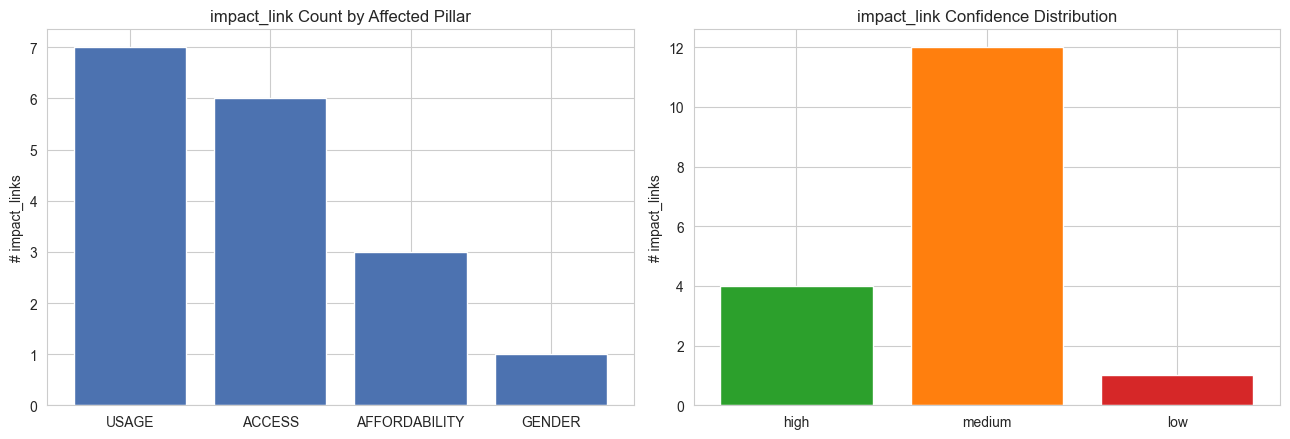

In [24]:
# (b) impact_link summary: which pillars have the most modeled evidence pointing to them?
links = review_impact_links(df)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

pillar_counts = links["pillar_impact"].value_counts()
axes[0].bar(pillar_counts.index, pillar_counts.values, color="#4c72b0")
axes[0].set_title("impact_link Count by Affected Pillar")
axes[0].set_ylabel("# impact_links")

conf_counts = links["confidence_impact"].value_counts().reindex(["high", "medium", "low"]).dropna()
axes[1].bar(conf_counts.index, conf_counts.values, color=[colors.get(c, "gray") for c in conf_counts.index])
axes[1].set_title("impact_link Confidence Distribution")
axes[1].set_ylabel("# impact_links")

plt.tight_layout()
plt.savefig(FIG_DIR / "impact_link_summary.png", dpi=150)
plt.show()


In [25]:
print("Which indicators have the most modeled relationships pointing at them?")
links["related_indicator_impact"].value_counts()


Which indicators have the most modeled relationships pointing at them?


related_indicator_impact
USG_P2P_COUNT         3
AFF_DATA_INCOME       3
ACC_OWNERSHIP         2
ACC_MM_ACCOUNT        2
USG_TELEBIRR_USERS    1
ACC_4G_COV            1
USG_MPESA_USERS       1
GEN_GAP_ACC           1
USG_MPESA_ACTIVE      1
ACC_AGENT_COUNT       1
USG_P2P_VALUE         1
Name: count, dtype: int64

**Reading the impact_link evidence as a proxy for "what's associated with what"**:
`ACC_OWNERSHIP` and `USG_P2P_COUNT` each have multiple independent impact_links pointing to
them from different events -- meaning several different mechanisms (product launches,
infrastructure, regulation) are all hypothesized to move these two indicators. That makes
them the two highest-leverage targets for the Task 3/4 modeling, which matches them being the
project's actual forecast targets. Most Access-side links are `literature`/`theoretical`
evidence rather than `empirical` Ethiopia-specific evidence -- a direct consequence of the
2021→2024 survey gap discussed in Section 5.


## 7. Key Insights

1. **Registered mobile money accounts (90M+) vastly outnumber active Findex-reported use
   (9.45%)** — roughly 120 registered accounts per 100 adults vs. under 10% actually reporting
   use in the past 12 months. This registered-vs-active gap is the single strongest candidate
   explanation for why Access grew only +3pp despite tens of millions of new accounts (Section 2).

2. **Most new mobile money accounts likely convert existing bank customers, not new-to-finance
   users.** Ethiopia's bank accounts were already fairly accessible pre-2021, and mobile-money-
   only users are rare (~0.5%, per the Market Nuances guide) — so mass Telebirr/M-Pesa signups
   plausibly move `ACC_MM_ACCOUNT` without moving headline `ACC_OWNERSHIP` at all.

3. **Agent network growth nearly stalled relative to account growth** (200k→216k agents,
   2022-2024, only +8%) while registered accounts grew far faster — a capacity bottleneck that
   would cap how many genuinely new, non-digitally-native users could actually be onboarded
   and served, regardless of how many apps get downloaded.

4. **The 2024 gender gap is real but its exact size is contested by the data itself.** Two
   independently reported figures for the same 2024 Findex round disagree (56%/36% vs.
   57%/42%) — logged in Task 1 as an unresolved conflict. Whichever is correct, women trail
   men by roughly 15-20pp in Access, and the gap in Usage (13pp, men 26% vs. women 13%) is
   proportionally even larger relative to the smaller overall base.

5. **Survey timing structurally limits event attribution.** Because Findex is only surveyed
   every ~3 years, Telebirr (2021), Safaricom's entry (2022), and M-Pesa (2023) all fall inside
   the same single 2021→2024 gap — the data cannot visually or statistically separate their
   individual effects on Access. Task 3's impact modeling will need comparable-country evidence
   to disentangle this, not just Ethiopia's own before/after numbers.

6. **Infrastructure enablers show a "funnel" pattern**: 4G network coverage is broad, but
   basic mobile phone ownership (41%) and especially smartphone penetration (16%) are much
   lower — the device/affordability layer, not the network layer, looks like the binding
   constraint on further digital Usage growth.


## Data Quality Assessment

**Confidence**: 73.6% of all records are rated high confidence, 25.0% medium, and a small
1.4% low-confidence tail (flagged conflicts, imprecise "fewer than one in four"-style
figures) — see the confidence bar chart in Section 1.

**Coverage gaps, in order of how much they limit this analysis:**
1. No urban/rural disaggregation anywhere in the dataset (`location` is always "national")
   despite Ethiopia's well-documented urban/rural inclusion gap.
2. No true infrastructure-density indicator (ATMs or bank branches per 100k adults) — only
   transaction counts/values exist for ATMs.
3. Most Task-1-added indicators (income quintiles, gender-usage-gap, smartphone penetration,
   agent count) have only 1-2 data points — enough for cross-sectional analysis (Section 3-4)
   but not for time-series forecasting on their own.
4. Findex's 3-year survey cadence means the entire 2021-2024 window is a single gap that three
   major events (Telebirr, Safaricom, M-Pesa) all fall inside — correlation/attribution between
   any one event and Access is not identifiable from Ethiopia data alone.
5. Two unresolved factual conflicts exist in the source data itself (2024 gender gap: 56/36 vs
   57/42; 2024 digital payment rate: ~35% per the project brief vs. 21% per direct Findex
   citation) — both logged, neither silently resolved.

**What this means for Task 3/4**: lean on `impact_link` evidence (much of it
`literature`/`theoretical`, i.e. comparable-country-based) rather than pure Ethiopia
before/after comparison, and present forecasts with wide uncertainty bands given how thin the
underlying time series are.


In [26]:
# Verify the confidence percentages cited in the markdown summary above
conf_pct = (df["confidence"].value_counts(normalize=True) * 100).round(1)
print(conf_pct)


confidence
high      73.6
medium    25.0
low        1.4
Name: proportion, dtype: float64
